# Fómula para cáculo da massa

$$ M^2 = 2 p_{T_1} p_{T_2} [ cosh(\eta_1 - \eta_2) - cos(\phi_1 - \phi_2) ] $$


In [306]:
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import vector
import hist
# import mplhep as hep
import coffea

In [307]:
path = '/opendata/eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/ZZTo4L_TuneCP5_13TeV_powheg_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/2430000/'
file = uproot.open(path + "051E9D22-4F30-8E49-8477-644E65768282.root")

In [308]:
print('Primeiro arquivo:', file1.keys())
tree = file['Events;1']

Primeiro arquivo: ['tag;1', 'Events;1', 'LuminosityBlocks;1', 'Runs;1', 'MetaData;1', 'ParameterSets;1']


In [309]:
tree.keys() # as outras trees possuem as mesmas variáveis

['run',
 'luminosityBlock',
 'event',
 'HTXS_Higgs_pt',
 'HTXS_Higgs_y',
 'HTXS_stage1_1_cat_pTjet25GeV',
 'HTXS_stage1_1_cat_pTjet30GeV',
 'HTXS_stage1_1_fine_cat_pTjet25GeV',
 'HTXS_stage1_1_fine_cat_pTjet30GeV',
 'HTXS_stage1_2_cat_pTjet25GeV',
 'HTXS_stage1_2_cat_pTjet30GeV',
 'HTXS_stage1_2_fine_cat_pTjet25GeV',
 'HTXS_stage1_2_fine_cat_pTjet30GeV',
 'HTXS_stage_0',
 'HTXS_stage_1_pTjet25',
 'HTXS_stage_1_pTjet30',
 'HTXS_njets25',
 'HTXS_njets30',
 'nboostedTau',
 'boostedTau_chargedIso',
 'boostedTau_eta',
 'boostedTau_leadTkDeltaEta',
 'boostedTau_leadTkDeltaPhi',
 'boostedTau_leadTkPtOverTauPt',
 'boostedTau_mass',
 'boostedTau_neutralIso',
 'boostedTau_phi',
 'boostedTau_photonsOutsideSignalCone',
 'boostedTau_pt',
 'boostedTau_puCorr',
 'boostedTau_rawAntiEle2018',
 'boostedTau_rawIso',
 'boostedTau_rawIsodR03',
 'boostedTau_rawMVAnewDM2017v2',
 'boostedTau_rawMVAoldDM2017v2',
 'boostedTau_rawMVAoldDMdR032017v2',
 'boostedTau_charge',
 'boostedTau_decayMode',
 'boostedTau_je

In [412]:
# ------------------------- Múons -------------------------

'''
# Selecionar 2 múons
valid_muon_pt = ak.num(muon_pt)>= 2
'''

muon_pt = tree['Muon_pt'].array()
muon_eta = tree['Muon_eta'].array()
muon_phi = tree['Muon_phi'].array()
muon_mass = tree['Muon_mass'].array()


valid_muon_pt = ak.num(muon_pt)>= 2
mask_muon = (muon_pt[valid_muon_pt][:, 0] > 20) & (np.abs(muon_eta[valid_muon_pt][:, 0] < 2.5))
mask_muon2 = (muon_pt[valid_muon_pt][:, 1] > 12) & (np.abs(muon_eta[valid_muon_pt][:, 1] < 2.5))
mask_muon_combined = mask_muon & mask_muon2


muon_pt_sel = muon_pt[valid_muon_pt][mask_muon_combined]
muon_eta_sel = muon_eta[valid_muon_pt][mask_muon_combined]
muon_phi_sel = muon_phi[valid_muon_pt][mask_muon_combined]
muon_mass_sel = muon_mass[valid_muon_pt][mask_muon_combined]



# ------------------------- Elétrons -------------------------

electron_pt = tree['Electron_pt'].array()
electron_eta = tree['Electron_eta'].array()
electron_phi = tree['Electron_phi'].array()
electron_mass = tree['Electron_mass'].array()

# Filtra eventos válidos com pelo menos 2 elétrons
valid_electron_pt = ak.num(electron_pt) >= 2

# Máscaras para o primeiro elétron
mask_electron_pt = electron_pt[valid_electron_pt][:, 0] > 20
mask_electron_eta = np.abs(electron_eta[valid_electron_pt][:, 0]) < 2.5

# Máscaras para o segundo elétron
mask_electron_pt2 = electron_pt[valid_electron_pt][:, 1] > 12
mask_electron_eta2 = np.abs(electron_eta[valid_electron_pt][:, 1]) < 2.5

# Máscara combinada
mask_electron_combined = mask_electron_pt & mask_electron_eta & mask_electron_pt2 & mask_electron_eta2


# Outra forma de fazer
# mask_elec = (electron_pt[valid_events_elec][:, 0] > 12.0) & (np.abs(electron_eta[valid_events_elec][:, 0]) < 2.4)
# mask_elec2 = (electron_pt[valid_events_elec][:, 1] > 4.0) & (np.abs(electron_eta[valid_events_elec][:, 1]) < 2.4)
# mask_electron_combined = mask_elec & mask_elec2


# Seleção final
electron_pt_sel = electron_pt[valid_electron_pt][mask_electron_combined]
electron_eta_sel = electron_eta[valid_electron_pt][mask_electron_combined]
electron_phi_sel = electron_phi[valid_electron_pt][mask_electron_combined]
electron_mass_sel = electron_mass[valid_electron_pt][mask_electron_combined]


# ------------------------- Taus -------------------------

tau_pt = tree['Tau_pt'].array()
tau_eta = tree['Tau_eta'].array()
tau_phi = tree['Tau_phi'].array()
tau_mass = tree['Tau_mass'].array()

# Filtra eventos válidos com pelo menos 2 taus
valid_tau_pt = ak.num(tau_pt) >= 2

# Máscaras para o primeiro tau
mask_tau_pt = tau_pt[valid_tau_pt][:, 0] > 20
mask_tau_eta = np.abs(tau_eta[valid_tau_pt][:, 0]) < 2.5

# Máscaras para o segundo tau
mask_tau_pt2 = tau_pt[valid_tau_pt][:, 1] > 12
mask_tau_eta2 = np.abs(tau_eta[valid_tau_pt][:, 1]) < 2.5

# Máscara combinada
mask_tau_combined = mask_tau_pt & mask_tau_eta & mask_tau_pt2 & mask_tau_eta2

# Seleção final
tau_pt_sel = tau_pt[valid_tau_pt][mask_tau_combined]
tau_eta_sel = tau_eta[valid_tau_pt][mask_tau_combined]
tau_phi_sel = tau_phi[valid_tau_pt][mask_tau_combined]
tau_mass_sel = tau_mass[valid_tau_pt][mask_tau_combined]


# ------------------------- Jatos -------------------------

jet_pt = tree['Jet_pt'].array()
jet_eta = tree['Jet_eta'].array()
jet_phi = tree['Jet_phi'].array()
jet_mass = tree['Jet_mass'].array()

# Filtra eventos válidos com pelo menos 2 jatos
valid_jet_pt = ak.num(jet_pt) >= 2

# Máscaras para o primeiro jato
mask_jet_pt = jet_pt[valid_jet_pt][:, 0] > 20
mask_jet_eta = np.abs(jet_eta[valid_jet_pt][:, 0]) < 2.5

# Máscaras para o segundo jato
mask_jet_pt2 = jet_pt[valid_jet_pt][:, 1] > 12
mask_jet_eta2 = np.abs(jet_eta[valid_jet_pt][:, 1]) < 2.5

# Máscara combinada
mask_jet_combined = mask_jet_pt & mask_jet_eta & mask_jet_pt2 & mask_jet_eta2

# Seleção final
jet_pt_sel = jet_pt[valid_jet_pt][mask_jet_combined]
jet_eta_sel = jet_eta[valid_jet_pt][mask_jet_combined]
jet_phi_sel = jet_phi[valid_jet_pt][mask_jet_combined]
jet_mass_sel = jet_mass[valid_jet_pt][mask_jet_combined]

In [311]:
# Remove listas vazias

# ------------------------- Múons -------------------------

muon_pt_clean = muon_pt_sel[ak.num(muon_pt_sel) > 0]
muon_eta_clean = muon_eta_sel[ak.num(muon_eta_sel) > 0]
muon_phi_clean = muon_phi_sel[ak.num(muon_phi_sel) > 0]
muon_mass_clean = muon_mass_sel[ak.num(muon_mass_sel) > 0]



print('pT:', muon_pt_clean)
print('eta:', muon_eta_clean)
print('phi:', muon_phi_clean)


# ------------------------- Elétrons -------------------------

electron_pt_clean = electron_pt_sel[ak.num(electron_pt_sel) > 0]
electron_eta_clean = electron_eta_sel[ak.num(electron_eta_sel) > 0]
electron_phi_clean = electron_phi_sel[ak.num(electron_phi_sel) > 0]
electron_mass_clean = electron_mass_sel[ak.num(electron_mass_sel) > 0]

# print('Electron pT:', electron_pt_clean)
# print('Electron eta:', electron_eta_clean)
# print('Electron phi:', electron_phi_clean)
# print('Electron mass:', electron_mass_clean)

# ------------------------- Taus -------------------------

tau_pt_clean = tau_pt_sel[ak.num(tau_pt_sel) > 0]
tau_eta_clean = tau_eta_sel[ak.num(tau_eta_sel) > 0]
tau_phi_clean = tau_phi_sel[ak.num(tau_phi_sel) > 0]
tau_mass_clean = tau_mass_sel[ak.num(tau_mass_sel) > 0]

# print('Tau pT:', tau_pt_clean)
# print('Tau eta:', tau_eta_clean)
# print('Tau phi:', tau_phi_clean)
# print('Tau mass:', tau_mass_clean)

# ------------------------- Jatos -------------------------

jet_pt_clean = jet_pt_sel[ak.num(jet_pt_sel) > 0]
jet_eta_clean = jet_eta_sel[ak.num(jet_eta_sel) > 0]
jet_phi_clean = jet_phi_sel[ak.num(jet_phi_sel) > 0]
jet_mass_clean = jet_mass_sel[ak.num(jet_mass_sel) > 0]

# print('Jet pT:', jet_pt_clean)
# print('Jet eta:', jet_eta_clean)
# print('Jet phi:', jet_phi_clean)
# print('Jet mass:', jet_mass_clean)



pT: [[23.6, 16.4, 12.4, 7.73], [59.3, 31.5], ..., [...], [77.9, 60.7, 57, 18.2]]
eta: [[1.89, 0.293, 0.827, 0.404], [1.22, ...], ..., [-1.18, -1.16, -1.2, 0.82]]
phi: [[2.71, 2.29, -1.71, 1.84], [2.65, ...], ..., [-1.74, -1.73, -1.82, 2.86]]


In [312]:
# Transformando array em 1D, para o plot

# ------------------------- Múons -------------------------

muon_pt_flat = ak.flatten(muon_pt_clean)
muon_eta_flat = ak.flatten(muon_eta_clean)
muon_phi_flat = ak.flatten(muon_phi_clean)
muon_mass_flat = ak.flatten(muon_mass_clean)

# ------------------------- Elétrons -------------------------

electron_pt_flat = ak.flatten(electron_pt_clean)
electron_eta_flat = ak.flatten(electron_eta_clean)
electron_phi_flat = ak.flatten(electron_phi_clean)
electron_mass_flat = ak.flatten(electron_mass_clean)

# ------------------------- Taus -------------------------

tau_pt_flat = ak.flatten(tau_pt_clean)
tau_eta_flat = ak.flatten(tau_eta_clean)
tau_phi_flat = ak.flatten(tau_phi_clean)
tau_mass_flat = ak.flatten(tau_mass_clean)

# ------------------------- Jatos -------------------------

jet_pt_flat = ak.flatten(jet_pt_clean)
jet_eta_flat = ak.flatten(jet_eta_clean)
jet_phi_flat = ak.flatten(jet_phi_clean)
jet_mass_flat = ak.flatten(jet_mass_clean)


In [338]:
# Quadri-Vetores

# ------------------------- Múons -------------------------

muon1_4vecs = vector.zip({
    "pt": muon_pt_clean[:, 0],
    "eta": muon_eta_clean[:, 0],
    "phi": muon_phi_clean[:, 0],
    "mass": muon_mass_clean[:, 0]
})

muon2_4vecs = vector.zip({
    "pt": muon_pt_clean[:, 1],
    "eta": muon_eta_clean[:, 1],
    "phi": muon_phi_clean[:, 1],
    "mass": muon_mass_clean[:, 1]
})

dimuon = muon1_4vecs + muon2_4vecs
mass_dimuon = dimuon.mass

# ------------------------- Elétrons -------------------------


electron1_4vecs = vector.zip({
    "pt": electron_pt_clean[:, 0],
    "eta": electron_eta_clean[:, 0],
    "phi": electron_phi_clean[:, 0],
    "mass": electron_mass_clean[:, 0]
})

electron2_4vecs = vector.zip({
    "pt": electron_pt_clean[:, 1],
    "eta": electron_eta_clean[:, 1],
    "phi": electron_phi_clean[:, 1],
    "mass": electron_mass_clean[:, 1]
})

dielectron = electron1_4vecs + electron2_4vecs
mass_dielectron = dielectron.mass
# ------------------------- Taus -------------------------

tau1_4vecs = vector.zip({
    "pt": tau_pt_clean[:, 0],
    "eta": tau_eta_clean[:, 0],
    "phi": tau_phi_clean[:, 0],
    "mass": tau_mass_clean[:, 0]
})

tau2_4vecs = vector.zip({
    "pt": tau_pt_clean[:, 1],
    "eta": tau_eta_clean[:, 1],
    "phi": tau_phi_clean[:, 1],
    "mass": tau_mass_clean[:, 1]
})

ditau = tau1_4vecs + tau2_4vecs
mass_ditau = ditau.mass
# ------------------------- Jatos -------------------------

jet1_4vecs = vector.zip({
    "pt": jet_pt_clean[:, 0],
    "eta": jet_eta_clean[:, 0],
    "phi": jet_phi_clean[:, 0],
    "mass": jet_mass_clean[:, 0]
})

jet2_4vecs = vector.zip({
    "pt": jet_pt_clean[:, 1],
    "eta": jet_eta_clean[:, 1],
    "phi": jet_phi_clean[:, 1],
    "mass": jet_mass_clean[:, 1]
})


dijet = jet1_4vecs + jet2_4vecs
mass_dijet = dijet.mass

In [377]:
#  -=-=-=-=-=-=-=-=-=- Variáveis para os plots antes dos cortes -=-=-=-=-=-=-=-=-=-

# ------------------------- Múons -------------------------
muon_pt_before_cut = tree['Muon_pt'].array()
muon_pt_before_cut_clean = muon_pt_before_cut[ak.num(muon_pt_before_cut) > 0]
muon_pt_before = ak.flatten(muon_pt_before_cut_clean)

muon_eta_before_cut = tree['Muon_eta'].array()
muon_eta_before_cut_clean = muon_eta_before_cut[ak.num(muon_eta_before_cut) > 0]
muon_eta_before = ak.flatten(muon_eta_before_cut_clean)

# ------------------------- Electron -------------------------
electron_pt_before_cut = tree['Electron_pt'].array()
electron_pt_before_cut_clean = electron_pt_before_cut[ak.num(electron_pt_before_cut) > 0]
electron_pt_before = ak.flatten(electron_pt_before_cut_clean)

electron_eta_before_cut = tree['Electron_eta'].array()
electron_eta_before_cut_clean = electron_eta_before_cut[ak.num(electron_eta_before_cut) > 0]
electron_eta_before = ak.flatten(electron_eta_before_cut_clean)

# ------------------------- Tau -------------------------
tau_pt_before_cut = tree['Tau_pt'].array()
tau_pt_before_cut_clean = tau_pt_before_cut[ak.num(tau_pt_before_cut) > 0]
tau_pt_before = ak.flatten(tau_pt_before_cut_clean)

tau_eta_before_cut = tree['Tau_eta'].array()
tau_eta_before_cut_clean = tau_eta_before_cut[ak.num(tau_eta_before_cut) > 0]
tau_eta_before = ak.flatten(tau_eta_before_cut_clean)

# ------------------------- Jet -------------------------
jet_pt_before_cut = tree['Jet_pt'].array()
jet_pt_before_cut_clean = jet_pt_before_cut[ak.num(jet_pt_before_cut) > 0]
jet_pt_before = ak.flatten(jet_pt_before_cut_clean)

jet_eta_before_cut = tree['Jet_eta'].array()
jet_eta_before_cut_clean = jet_eta_before_cut[ak.num(jet_eta_before_cut) > 0]
jet_eta_before = ak.flatten(jet_eta_before_cut_clean)


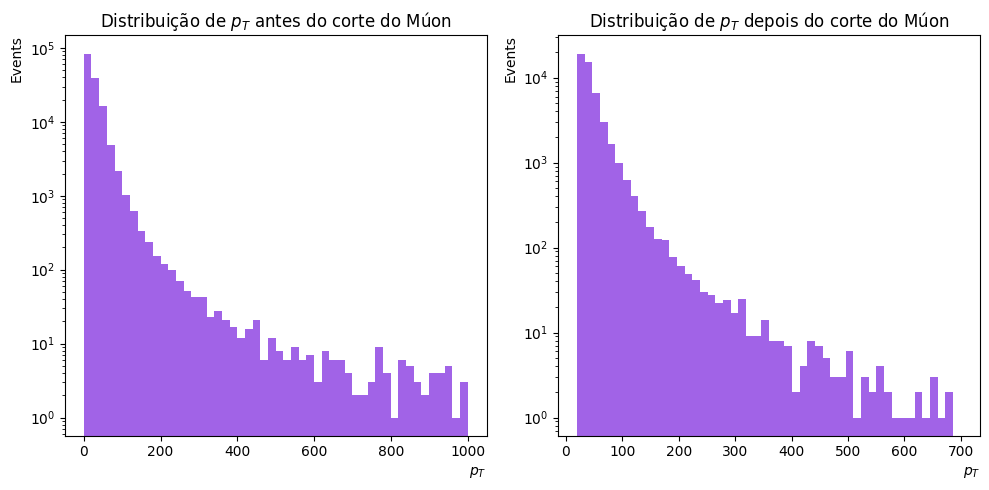

In [416]:
# /\/\/\/\/\//\/\/\ MUON PT /\/\/\/\/\//\/\/\
plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
plt.subplot(1, 2, 1)
plt.hist(muon_pt_before, bins=50, color='#7a21dd', alpha=0.7, range=(0, 1000))
plt.yscale('log')
plt.title(r'Distribuição de $p_T$ antes do corte do Múon')
plt.xlabel(r"$p_{T}$",  loc='right')
plt.ylabel("Events", loc='top')


plt.subplot(1, 2, 2)
plt.hist(muon_pt_flat, bins=50, color='#7a21dd', alpha=0.7, range=(20, 700))
plt.yscale('log')
plt.title(r'Distribuição de $p_T$ depois do corte do Múon')#, loc = 'left')
plt.xlabel(r"$p_{T}$",  loc='right')
plt.ylabel("Events", loc='top')

plt.tight_layout()
# plt.savefig("pt_muons.png", dpi = 300)
plt.show()


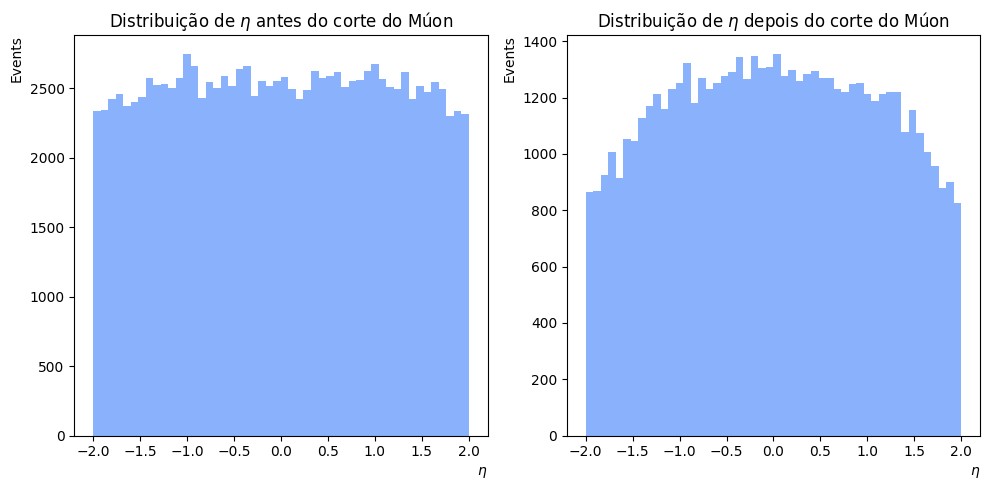

In [418]:
# /\/\/\/\/\//\/\/\ MUON ETA /\/\/\/\/\//\/\/\
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(muon_eta_before, bins=50, color='#5790fc', alpha=0.7, range=(-2, 2))
plt.title("Distribuição de $\eta$ antes do corte do Múon")
plt.xlabel(r"$\eta$", loc='right')
plt.ylabel("Events", loc='top')

plt.subplot(1, 2, 2)
plt.hist(muon_eta_flat, bins=50, color='#5790fc', alpha=0.7, range=(-2, 2))
plt.title("Distribuição de $\eta$ depois do corte do Múon")
plt.xlabel(r"$\eta$", loc='right')
plt.ylabel("Events", loc='top')

plt.tight_layout()
# plt.savefig("eta_muons.png", dpi = 300)
plt.show()


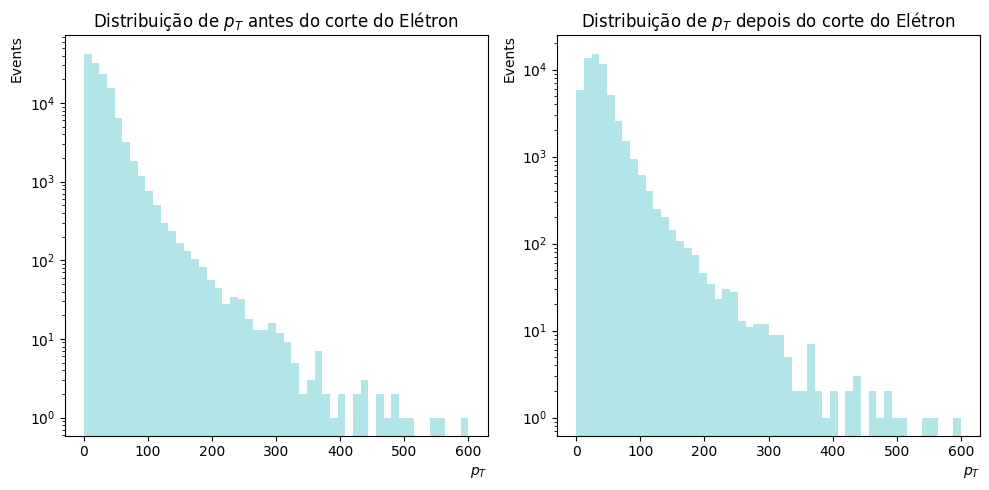

In [420]:
# /\/\/\/\/\//\/\/\ ELÉTRON PT /\/\/\/\/\//\/\/\
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(electron_pt_before, bins=50, color='#92dadd', alpha=0.7, range=(0, 600))
plt.title(r"Distribuição de $p_T$ antes do corte do Elétron")
plt.xlabel(r"$p_T$", loc='right')
plt.ylabel("Events", loc='top')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.hist(electron_pt_flat, bins=50, color='#92dadd', alpha=0.7, range=(0, 600))
plt.title(r"Distribuição de $p_T$ depois do corte do Elétron")
plt.xlabel(r"$p_T$", loc='right')
plt.ylabel("Events", loc='top')
plt.yscale('log')

plt.tight_layout()
# plt.savefig("pt_eletron.png", dpi=300)
plt.show()


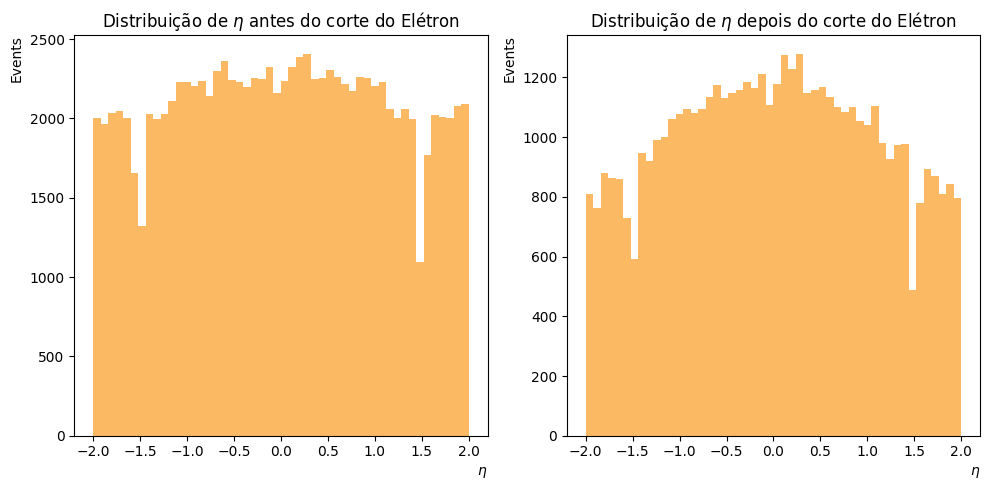

In [422]:
# /\/\/\/\/\//\/\/\ ELÉTRON ETA /\/\/\/\/\//\/\/\
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(electron_eta_before, bins=50, color='#f89c20', alpha=0.7, range=(-2, 2))
plt.title("Distribuição de $\eta$ antes do corte do Elétron")
plt.xlabel(r"$\eta$", loc='right')
plt.ylabel("Events", loc='top')

plt.subplot(1, 2, 2)
plt.hist(electron_eta_flat, bins=50, color='#f89c20', alpha=0.7, range=(-2, 2))
plt.title("Distribuição de $\eta$ depois do corte do Elétron")
plt.xlabel(r"$\eta$", loc='right')
plt.ylabel("Events", loc='top')

plt.tight_layout()
# plt.savefig("eta_eletron.png", dpi=300)
plt.show()


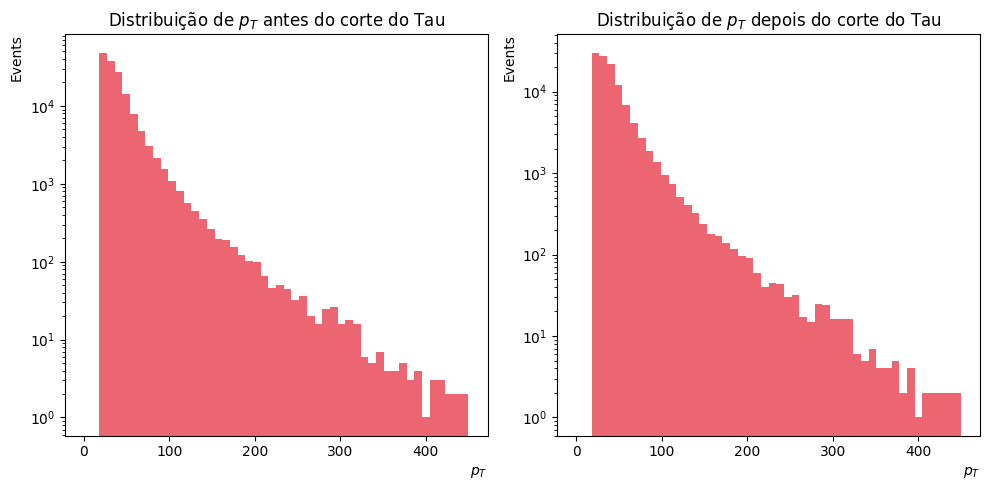

In [424]:
# /\/\/\/\/\//\/\/\ TAU PT /\/\/\/\/\//\/\/\

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(tau_pt_before, bins=50, color='#e42536', alpha=0.7, range=(0, 450))
plt.title("Distribuição de $p_T$ antes do corte do Tau")
plt.xlabel(r"$p_T$", loc='right')
plt.ylabel("Events", loc='top')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.hist(tau_pt_flat, bins=50, color='#e42536', alpha=0.7, range=(0, 450))
plt.title("Distribuição de $p_T$ depois do corte do Tau")
plt.xlabel(r"$p_T$", loc='right')
plt.ylabel("Events", loc='top')
plt.yscale('log')

plt.tight_layout()
# plt.savefig("pt_tau.png", dpi=300)
plt.show()

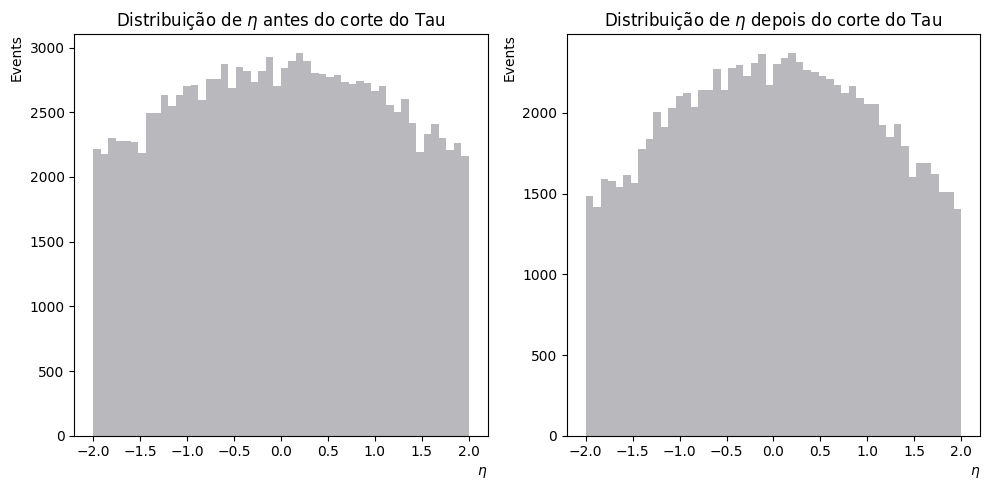

In [426]:
# /\/\/\/\/\//\/\/\ TAU ETA /\/\/\/\/\//\/\/\
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(tau_eta_before, bins=50, color='#9c9ca1', alpha=0.7, range=(-2, 2))
plt.title("Distribuição de $\eta$ antes do corte do Tau")
plt.xlabel(r"$\eta$", loc='right')
plt.ylabel("Events", loc='top')

plt.subplot(1, 2, 2)
plt.hist(tau_eta_flat, bins=50, color='#9c9ca1', alpha=0.7, range=(-2, 2))
plt.title("Distribuição de $\eta$ depois do corte do Tau")
plt.xlabel(r"$\eta$", loc='right')
plt.ylabel("Events", loc='top')

plt.tight_layout()
# plt.savefig("eta_tau.png", dpi=300)
plt.show()

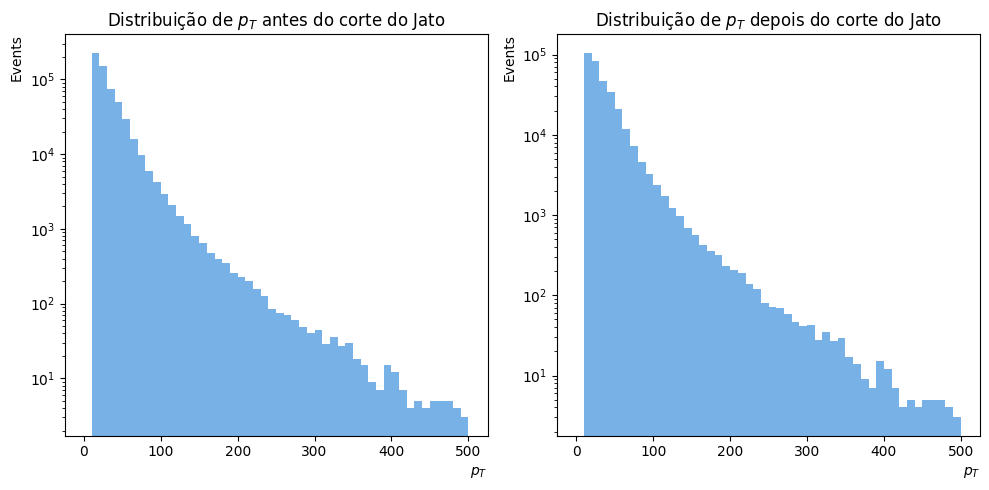

In [428]:
# /\/\/\/\/\//\/\/\ JET PT /\/\/\/\/\//\/\/
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(jet_pt_before, bins=50, color='#3f90da', alpha=0.7, range=(0, 500))
plt.title("Distribuição de $p_T$ antes do corte do Jato")
plt.xlabel(r"$p_T$", loc='right')
plt.ylabel("Events", loc='top')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.hist(jet_pt_flat, bins=50, color='#3f90da', alpha=0.7, range=(0, 500))
plt.title("Distribuição de $p_T$ depois do corte do Jato")
plt.xlabel(r"$p_T$", loc='right')
plt.ylabel("Events", loc='top')
plt.yscale('log')

plt.tight_layout()
# plt.savefig("pt_jet.png", dpi=300)
plt.show()

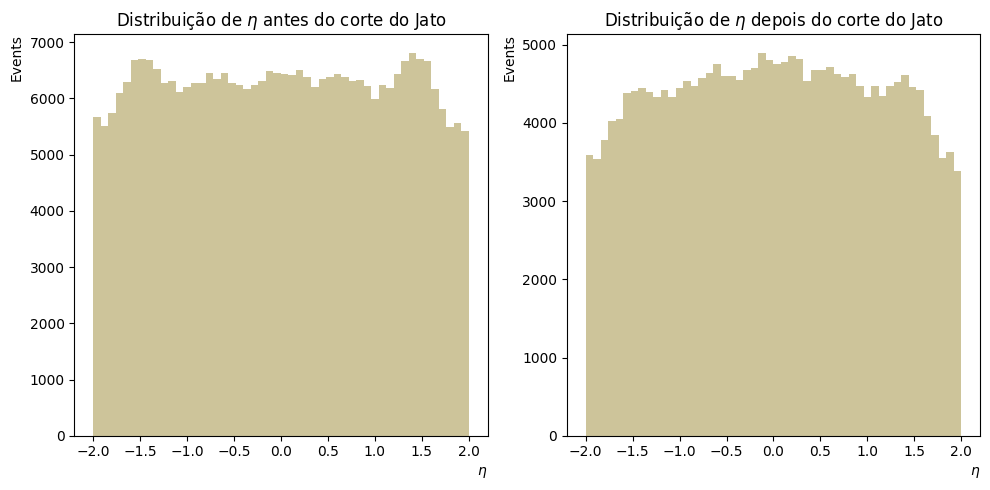

In [431]:
# /\/\/\/\/\//\/\/\ JET ETA /\/\/\/\/\//\/\/
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(jet_eta_before, bins=50, color='#b9ac70', alpha=0.7, range=(-2, 2))
plt.title("Distribuição de $\eta$ antes do corte do Jato")
plt.xlabel(r"$\eta$", loc='right')
plt.ylabel("Events", loc='top')

plt.subplot(1, 2, 2)
plt.hist(jet_eta_flat, bins=50, color='#b9ac70', alpha=0.7, range=(-2, 2))
plt.title("Distribuição de $\eta$ depois do corte do Jato")
plt.xlabel(r"$\eta$", loc='right')
plt.ylabel("Events", loc='top')

plt.tight_layout()
# plt.savefig("eta_jet.png", dpi=300)
plt.show()

## Plot Massa

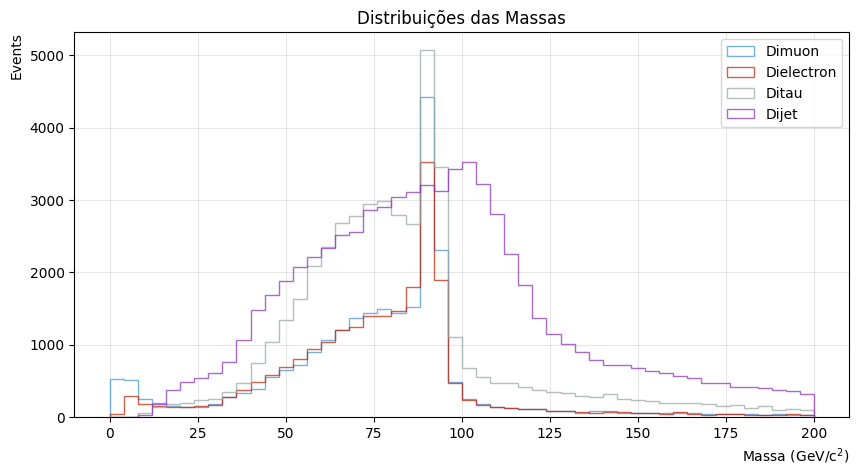

In [433]:
plt.figure(figsize=(10, 5))

# Plot de cada variável
plt.hist(mass_dimuon, bins=50, color='#3f90da', alpha=0.7, label='Dimuon', histtype='step', range = (0,200))
plt.hist(mass_dielectron, bins=50, color='#bd1f01', alpha=0.7, label='Dielectron', histtype='step', range = (0,200))
plt.hist(mass_ditau, bins=50, color='#94a4a2', alpha=0.7, label='Ditau', histtype='step', range = (0,200))
plt.hist(mass_dijet, bins=50, color='#832db6', alpha=0.7, label='Dijet', histtype='step', range = (0,200))

# Configurações do gráfico
plt.title("Distribuições das Massas")
plt.xlabel(r"Massa (GeV/c$^2$)", loc='right')
plt.ylabel("Events", loc='top')
plt.legend(loc='best')
plt.grid(alpha=0.3)
# plt.savefig("mass.png", dpi=300)
plt.show()
